# Retail Sales Performance Analysis

## Project Overview

This project analyses retail transaction data to evaluate sales performance, profitability, regional performance and the impact of discounting.

The objective is to identify important business trends, underperforming areas and opportunities to improve profitability.

### Business Questions

1. How have sales changed over time?
2. Which product categories and sub-categories generate the most profit?
3. Which regions perform best?
4. How does discounting affect profitability?
5. Which individual products generate the highest profits and losses?

### Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab

### Dataset

The analysis uses the Sample Superstore retail dataset. The Orders sheet contains 10,194 transaction-level records across sales, customers, products, regions, discounts and profit.


## 1. Environment Setup

The `xlrd` package is installed so that Pandas can read the `.xls` workbook used in this project.


In [5]:
!pip install xlrd -q

## 2. Import Libraries


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 3. Load the Dataset

The Orders sheet is loaded into a Pandas DataFrame for analysis.

> **Colab note:** If the runtime resets, upload `sample_-_superstore.xls` to the Colab session again before running this cell.


In [7]:
file_path = "/content/sample_-_superstore.xls"

df = pd.read_excel(file_path, sheet_name="Orders")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 4. Data Exploration and Quality Checks

Before analysing the business, the dataset is inspected for structure, data types, missing values, unusual numerical ranges and duplicate rows.


### Column Names


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

### Dataset Size


In [9]:
df.shape

(10194, 21)

### Data Types and Completeness


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

### Missing Values


In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


### Descriptive Statistics


In [12]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


### Duplicate Records


In [13]:
df.duplicated().sum()

np.int64(0)

### Data Quality Summary

The dataset contains **10,194 rows and 21 original variables**. No missing values or fully duplicated rows were identified. Order Date and Ship Date are already stored as date variables, while Sales, Discount and Profit are numeric and ready for analysis.


## 5. Feature Engineering

A separate analysis copy is created so the original DataFrame remains unchanged. Four additional fields are added:

- **Year** for annual trend analysis
- **Month** for readable monthly labels
- **Month Number** for chronological month ordering
- **Profit Margin** to measure profitability relative to sales


In [14]:
df_clean = df.copy()

In [15]:
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month_name()
df_clean["Month Number"] = df_clean["Order Date"].dt.month
df_clean["Profit Margin"] = (df_clean["Profit"] / df_clean["Sales"]) * 100

In [16]:
df_clean.shape

(10194, 25)

## 6. Key Performance Indicators

The first step in the business analysis is to establish the overall size and profitability of the business.


In [17]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
overall_profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Total Sales: 2326534.35
Total Profit: 292296.81
Total Orders: 5111
Total Customers: 804
Overall Profit Margin: 12.56 %


### KPI Summary

| KPI | Result |
|---|---:|
| Total Sales | **$2.33 million** |
| Total Profit | **$292,296.81** |
| Total Orders | **5,111** |
| Total Customers | **804** |
| Overall Profit Margin | **12.56%** |

Overall, the business generated a positive profit and retained approximately **$12.56 in profit for every $100 of sales**.


## 7. Sales Performance Over Time

### Monthly Sales Trend

Monthly transaction data is aggregated to identify the overall pattern and volatility of sales over time.


In [18]:
monthly_sales = (
    df_clean.groupby(
        df_clean["Order Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2023-01,14518.055
2023-02,4519.892
2023-03,56933.909
2023-04,28295.345
2023-05,26319.767


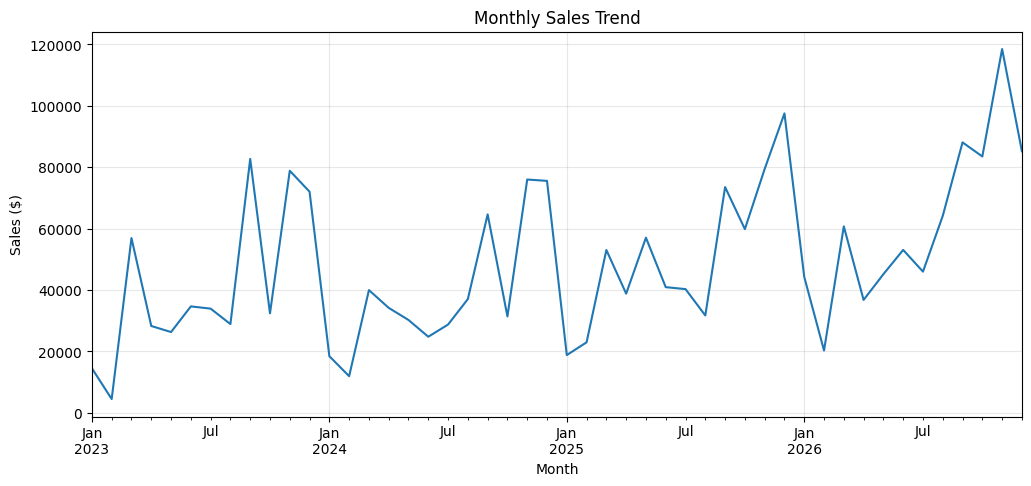

In [19]:
monthly_sales.plot(figsize=(12, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True, alpha=0.3)

plt.show()

### Annual Sales Performance

Yearly totals are used to confirm whether the longer-term trend observed in the monthly chart represents genuine growth.


In [20]:
yearly_sales = df_clean.groupby("Year")["Sales"].sum()

yearly_sales

,Sales
Year,
2023,494040.2121
2024,472993.0310
2025,613933.5800
2026,745567.5312


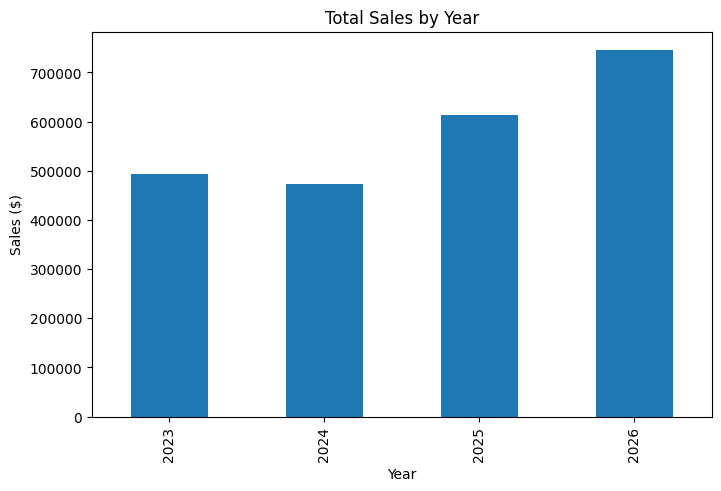

In [21]:
yearly_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales ($)")

plt.show()

### Year-on-Year Sales Growth


In [22]:
yearly_sales_growth = yearly_sales.pct_change() * 100

yearly_sales_growth

,Sales
Year,
2023,NaN
2024,-4.260216
2025,29.797595
2026,21.441074


### Sales Insight

Sales declined slightly in **2024 (-4.3%)**, before recovering strongly in **2025 (+29.8%)** and continuing to grow in **2026 (+21.4%)**.

Total sales increased from approximately **$494,040 in 2023** to **$745,568 in 2026**, representing overall growth of approximately **50.9%** across the period. This indicates strong recent sales momentum despite the temporary decline in 2024.


## 8. Product Category and Sub-Category Performance

### Category Performance

Sales and profit are compared across the three main product categories.


In [23]:
category_performance = (
    df_clean.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit
Category,,
Technology,839893.2790,146543.3756
Furniture,754747.7613,19729.9956
Office Supplies,731893.3140,126023.4434


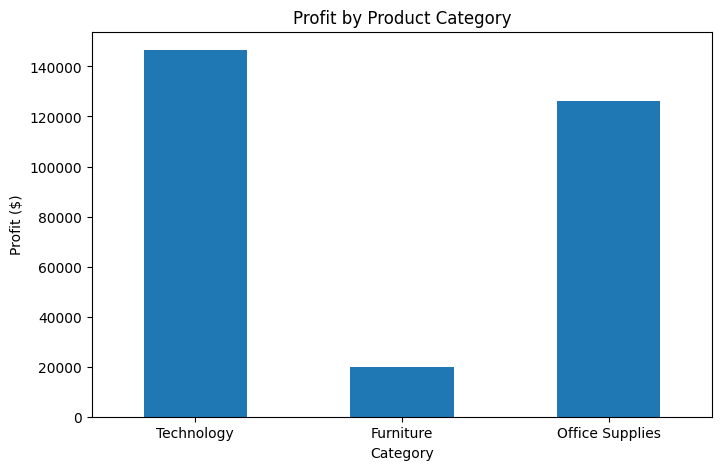

In [24]:
category_performance["Profit"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

### Category Insight

**Technology** generated the highest profit at approximately **$146,543**, followed by **Office Supplies** at approximately **$126,023**.

Although **Furniture** generated substantial sales of approximately **$754,748**, it produced only about **$19,730 in profit**, indicating much weaker profitability than the other major categories.


### Sub-Category Performance

The analysis is then drilled down to sub-category level to identify the specific product groups driving the result.


In [25]:
subcat_performance = (
    df_clean.groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit")
)

subcat_performance

,Sales,Profit
Sub-Category,,
Tables,208020.1820,-17753.2061
Bookcases,115361.2043,-3632.0736
Supplies,46725.4980,-1171.3945
Fasteners,8532.2400,2428.6358
Machines,189925.0310,3461.9769
Labels,12695.0420,5572.7780
Art,27659.0140,6653.1962
Envelopes,16528.3620,6988.0247
Furnishings,95598.1260,13891.7430


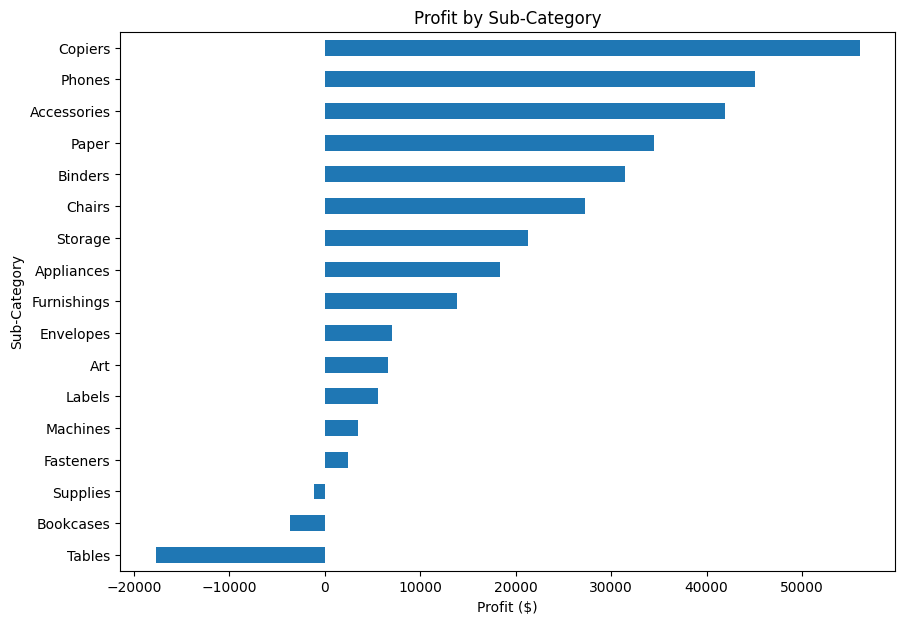

In [26]:
subcat_performance["Profit"].plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.show()

### Sub-Category Insight

Profit is concentrated in strong performers such as **Copiers, Phones and Accessories**. In contrast, **Tables** are the largest loss-making sub-category, followed by **Bookcases** and **Supplies**.

This shows that Furniture's weak profitability is not uniform across the entire category and is driven particularly by loss-making sub-categories.


### Investigating Table Profitability

Tables generated meaningful revenue but produced an overall loss, so discounting is examined as a possible contributor.


In [27]:
table_analysis = (
    df_clean[df_clean["Sub-Category"] == "Tables"]
    .agg({
        "Sales": "sum",
        "Profit": "sum",
        "Discount": "mean",
        "Quantity": "sum"
    })
)

table_analysis

,0
Sales,208020.182000
Profit,-17753.206100
Discount,0.258129
Quantity,1261.000000


In [28]:
df_clean.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False)

,Discount
Sub-Category,
Binders,0.369057
Machines,0.304274
Tables,0.258129
Bookcases,0.215259
Chairs,0.169243
Appliances,0.164557
Copiers,0.157143
Phones,0.152602
Furnishings,0.138057


In [29]:
table_discount_analysis = (
    df_clean[df_clean["Sub-Category"] == "Tables"]
    .groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)

table_discount_analysis

,Sales,Profit,Orders
Discount,,,
0.00,71706.230,13334.9247,74
0.20,45636.582,-298.3980,70
0.30,25902.980,-3493.8376,53
0.40,45614.406,-16187.3968,72
0.45,5484.974,-2493.1111,10
0.50,13675.010,-8615.3873,35


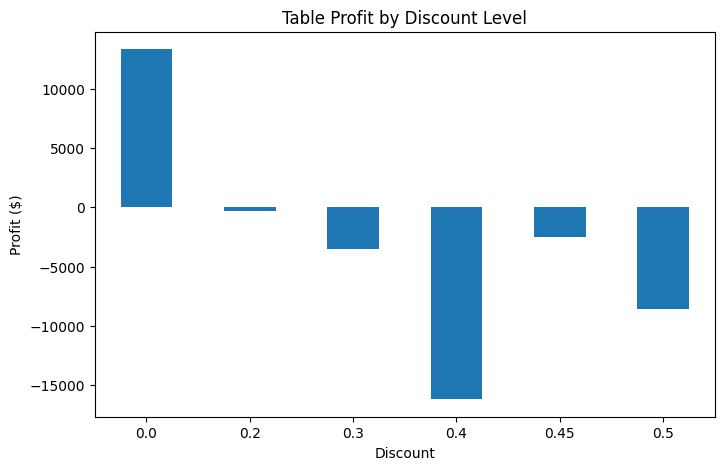

In [30]:
table_discount_analysis["Profit"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Table Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

### Tables Finding

Tables generated approximately **$208,020 in sales** but recorded an overall loss of approximately **$17,753**. Their average discount was approximately **25.8%**, one of the highest among all sub-categories.

Non-discounted Table sales were profitable, while discounted Table sales were consistently loss-making. The largest loss occurred at a **40% discount**.

This indicates a strong **association** between heavier discounting and weaker profitability for Tables. The analysis is descriptive and does not, by itself, prove that discounting caused the losses.


## 9. Regional Performance

### Sales and Profit by Region


In [31]:
region_performance = (
    df_clean.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit", ascending=False)
)

region_performance

,Sales,Profit
Region,,
West,739813.6085,110798.8170
East,691828.1680,94883.2603
South,391721.9050,46749.4303
Central,503170.6728,39865.3070


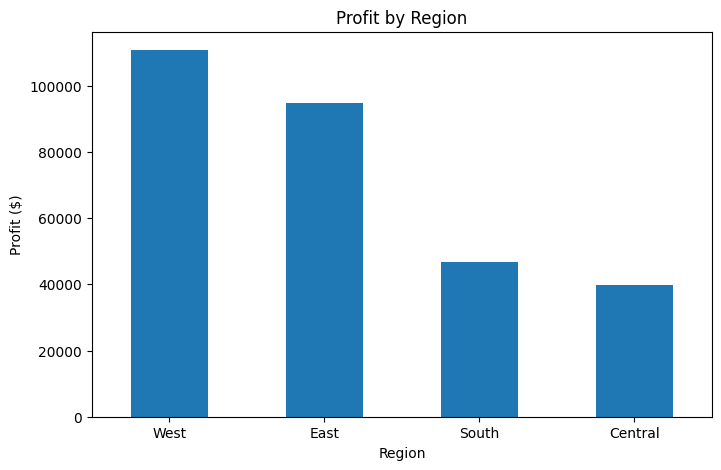

In [32]:
region_performance["Profit"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

### Regional Insight

The **West** region was the strongest performer, generating approximately **$739,814 in sales** and **$110,799 in profit**.

The **Central** region generated more sales than the South but produced less profit, suggesting weaker profit efficiency.


### Investigating the Central Region

Sub-category performance within Central is examined to determine whether the region's weaker margin is caused by one product group or a broader pattern.


In [33]:
central_analysis = (
    df_clean[df_clean["Region"] == "Central"]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

central_analysis

,Sales,Profit,Avg_Discount
Sub-Category,,,
Furnishings,15284.3620,-3915.5153,0.403865
Tables,39154.9710,-3559.6504,0.262500
Appliances,23582.0330,-2638.6175,0.448780
Bookcases,24157.1768,-1997.9043,0.232800
Machines,26797.3840,-1486.0666,0.328571
Binders,58060.7900,-958.3051,0.508602
Supplies,9467.3720,-661.8881,0.144444
Fasteners,778.0300,236.6186,0.134545
Labels,2451.4720,1073.0794,0.113158


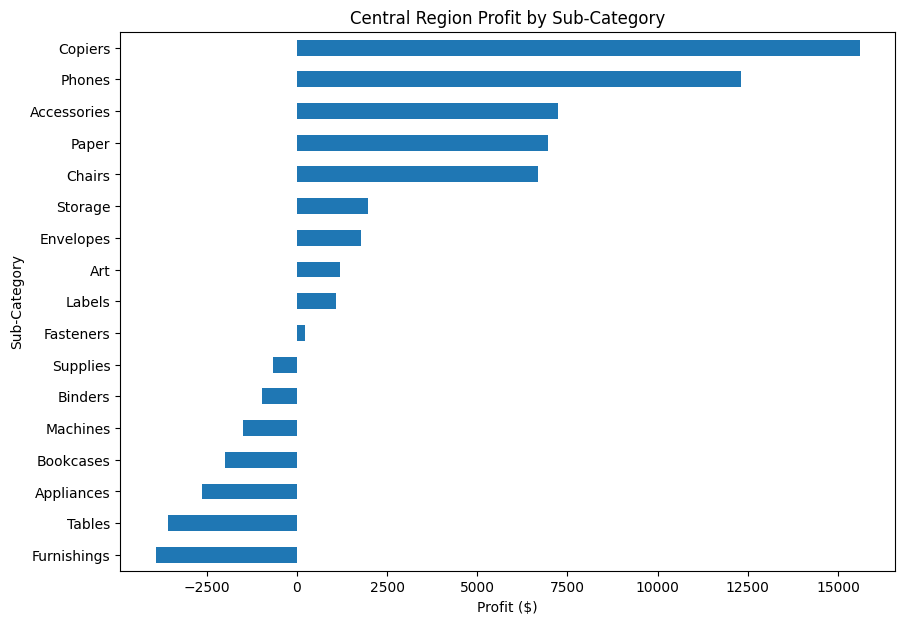

In [34]:
central_analysis["Profit"].plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Central Region Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.show()

In [35]:
region_discount = (
    df_clean.groupby("Region")
    .agg(
        Avg_Discount=("Discount", "mean"),
        Profit=("Profit", "sum"),
        Sales=("Sales", "sum")
    )
)

region_discount["Profit_Margin"] = (
    region_discount["Profit"] / region_discount["Sales"]
) * 100

region_discount

,Avg_Discount,Profit,Sales,Profit_Margin
Region,,,,
Central,0.241002,39865.3070,503170.6728,7.922820
East,0.143436,94883.2603,691828.1680,13.714859
South,0.147253,46749.4303,391721.9050,11.934342
West,0.108946,110798.8170,739813.6085,14.976585


### Central Region Finding

Central's profitability problem is broader than one sub-category. Several groups, including **Furnishings, Tables, Appliances, Bookcases and Machines**, generated losses, although profitable areas such as **Copiers and Phones** partly offset them.

Central also had the **highest average discount at approximately 24.1%** and the **lowest regional profit margin at approximately 7.9%**. By comparison, West had the lowest average discount at approximately **10.9%** and the highest regional profit margin at approximately **15.0%**.

This suggests that heavier discounting may be contributing to Central's weaker profitability.


## 10. Impact of Discounting

Discount levels are analysed across the entire business to determine whether the pattern observed in Tables and Central also appears at company level.


In [36]:
discount_performance = (
    df_clean.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)

discount_performance

,Sales,Profit,Orders
Discount,,,
0.00,1.105324e+06,326718.5872,2714
0.10,5.495250e+04,9099.9700,91
0.15,2.755852e+04,1418.9915,51
0.20,7.739394e+05,91079.9517,2440
0.30,1.044741e+05,-10513.4456,214
0.32,1.449346e+04,-2391.1377,27
0.40,1.164978e+05,-23086.3742,186
0.45,5.484974e+03,-2493.1111,10
0.50,5.891854e+04,-20506.4281,64


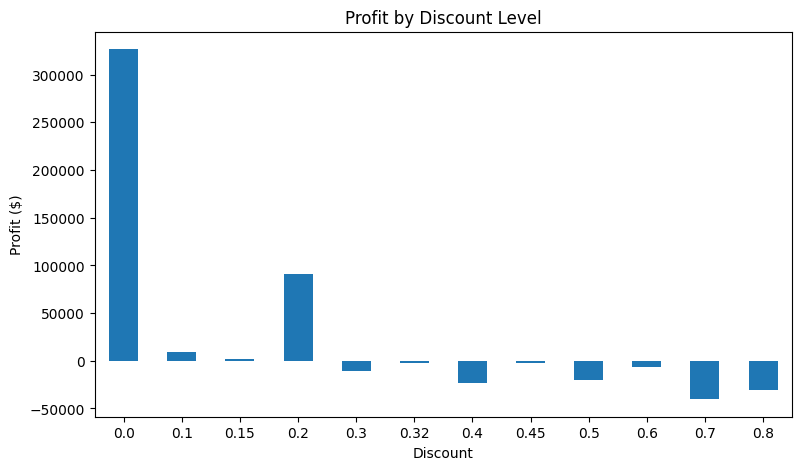

In [37]:
discount_performance["Profit"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

### Profit Margin by Discount Level

Profit margin provides a more comparable measure than total profit because discount levels have different sales volumes and numbers of orders.


In [38]:
discount_performance["Profit_Margin"] = (
    discount_performance["Profit"] / discount_performance["Sales"]
) * 100

discount_performance[
    ["Sales", "Profit", "Orders", "Profit_Margin"]
]

,Sales,Profit,Orders,Profit_Margin
Discount,,,,
0.00,1.105324e+06,326718.5872,2714,29.558632
0.10,5.495250e+04,9099.9700,91,16.559702
0.15,2.755852e+04,1418.9915,51,5.149012
0.20,7.739394e+05,91079.9517,2440,11.768357
0.30,1.044741e+05,-10513.4456,214,-10.063211
0.32,1.449346e+04,-2391.1377,27,-16.498047
0.40,1.164978e+05,-23086.3742,186,-19.817012
0.45,5.484974e+03,-2493.1111,10,-45.453472
0.50,5.891854e+04,-20506.4281,64,-34.804712


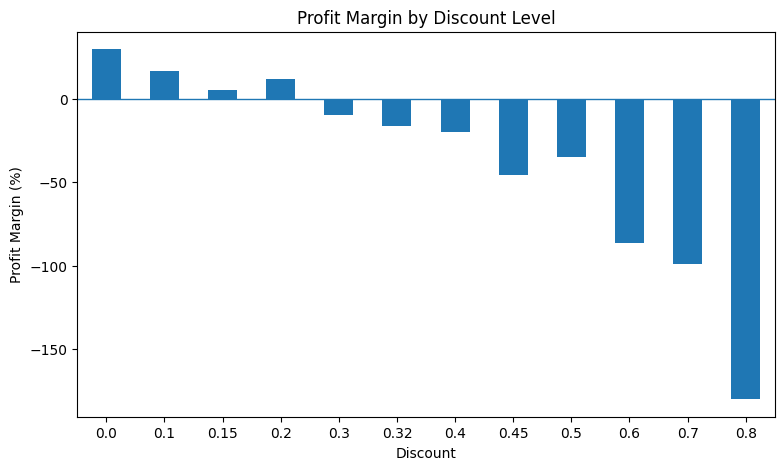

In [39]:
discount_performance["Profit_Margin"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Profit Margin by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)

plt.show()

### Discounting Insight

Profitability declines sharply as discount levels increase.

- Sales with **0% to 20% discounts** remained profitable overall.
- At **30% discount**, the overall profit margin became negative.
- Higher discount levels were associated with progressively larger negative margins.
- The **80% discount** level produced an overall profit margin below -100%, meaning the losses exceeded the sales revenue generated at that discount level.

The results indicate that aggressive discounting represents a significant profitability risk. Because this is observational data, the finding should be interpreted as an association rather than proof of causation.


## 11. Product-Level Performance

The final analysis identifies the individual products that contribute the most to profit and those that generate the largest losses.


In [40]:
product_performance = (
    df_clean.groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Profit")
)

product_performance.head(10)

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


### Ten Most Profitable Products


In [41]:
product_performance.tail(10)

,Sales,Profit,Quantity
Product Name,,,
Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31


### Ten Largest Loss-Making Products


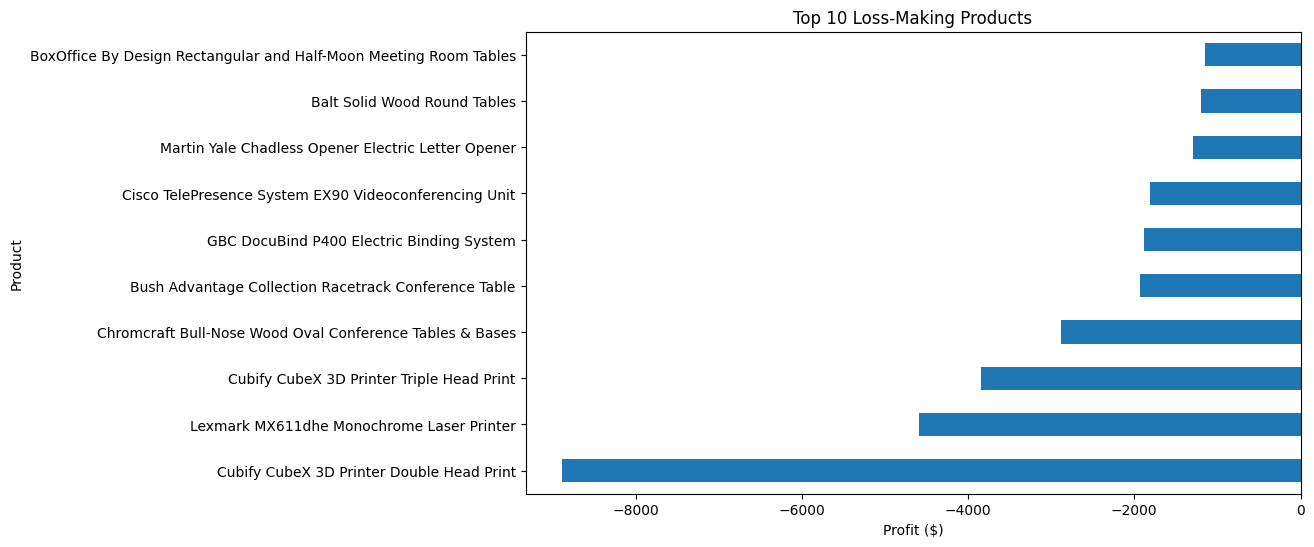

In [42]:
worst_products = product_performance.head(10)

worst_products["Profit"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit ($)")
plt.ylabel("Product")

plt.show()

### Ten Most Profitable Products


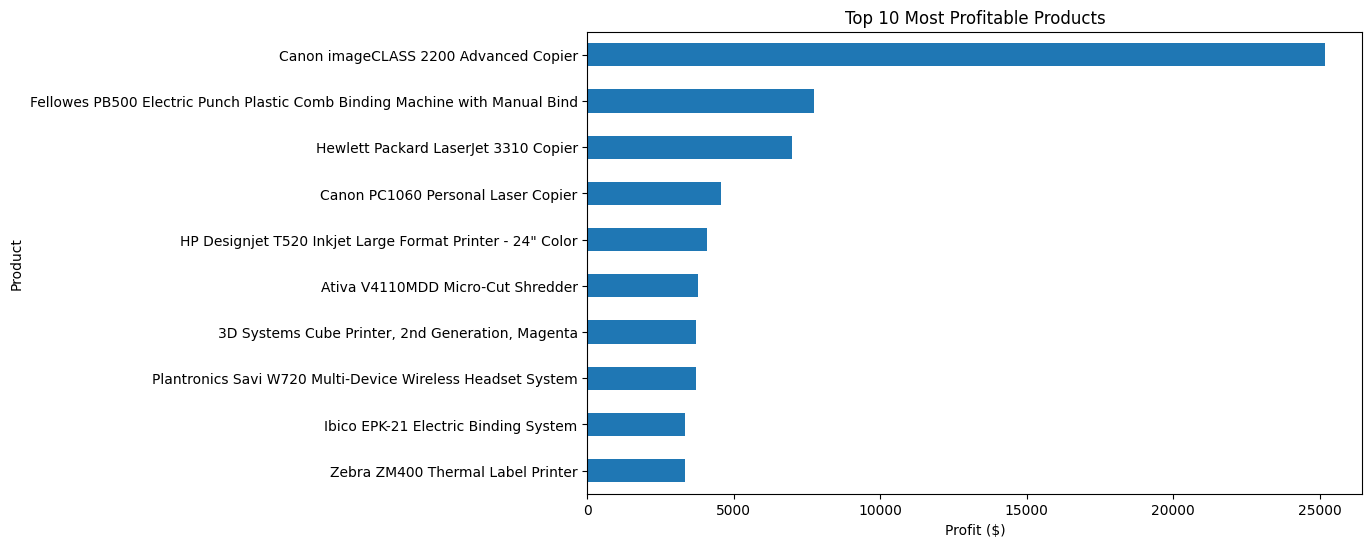

In [43]:
best_products = product_performance.tail(10)

best_products["Profit"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Profit ($)")
plt.ylabel("Product")

plt.show()

### Product-Level Insight

The **Canon imageCLASS 2200 Advanced Copier** was the strongest individual product in the dataset, generating approximately **$25,200 in profit**.

The largest individual loss came from the **Cubify CubeX 3D Printer Double Head Print**, which recorded approximately **$8,880 in losses**.

This highlights why sales revenue alone is not enough for product decisions. Individual products should also be monitored for profitability, discounting and cost performance.


## 12. Business Recommendations

Based on the descriptive analysis:

1. **Review high-discount transactions**, especially discounts of 30% or more, because these levels are associated with negative overall profit margins.
2. **Investigate the pricing and cost structure of Tables**, particularly heavily discounted Table transactions.
3. **Review underperforming Central-region sub-categories**, where several product groups are loss-making and average discounts are comparatively high.
4. **Protect strong profit contributors** such as Technology, Copiers, Phones and other high-performing products while monitoring their margins.
5. **Use profitability alongside sales revenue** when assessing products, regions and promotional decisions.

## Conclusion

The business shows strong recent sales growth, with sales increasing by approximately **50.9% from 2023 to 2026**. However, profitability varies substantially across categories, sub-categories, regions and discount levels.

The clearest opportunity identified in this analysis is improved **discount discipline**, particularly for loss-making products and weaker-performing areas such as Tables and the Central region.

## Limitations

This project is a descriptive exploratory analysis. Relationships identified in the data, such as the association between higher discounts and lower profitability, should not be interpreted as causal without additional modelling or experimental evidence.
